In [2]:
# conda activate meteor (becasue python 9 is installed here)
# rm -r venv
# make first-venv
# make clean
# make virtual-environment
# source venv/bin/activate
# then select the kernel 'venv' in jupyter notebook

import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from dataclasses import asdict
import warnings
from pandas.errors import SettingWithCopyWarning
from functools import partial
#warnings.filterwarnings('ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
#warnings.filterwarnings("ignore", message=".*not in pamset.*")

from meteor import MeteorPatternScaling, meteor_plot_utils
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
from meteor import scm_forcer_engine
from ciceroscm import CICEROSCM
from ciceroscm import input_handler

from meteor.prpatt import global_mean
from meteor.prpatt import recon

import cartopy.crs as ccrs
import cartopy as cart
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy.interpolate import griddata
import matplotlib.ticker as mticker
from scipy.stats import pearsonr
from tqdm import tqdm

In [3]:
cachedir = os.path.join(os.getcwd(), "cache")
if not os.path.exists(cachedir):
        os.makedirs(cachedir)
        
figdir = os.path.join(os.getcwd(), "figures")
if not os.path.exists(figdir):
        os.makedirs(figdir)

cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

# Data preparations

### Getting some data that can be used by the forcer engine and ciceroscm

SSP245 for aerorol residual from abrupt-4xCO2

In [4]:
%%capture
ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

#For predictions: 
conc_data = input_handler.read_inputfile(os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt"))
em_data = ih.read_emissions(os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt"))

standard SSP scenarios

In [5]:
scenarios = [ "ssp126", "ssp245", "ssp370", "ssp585"]

In [19]:
%%capture
#For predictions: read in SSP concentrations and emissions
#scenarios = ["ssp126","ssp245","ssp370","ssp585"]

ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

conc_data_fwd=[]
em_data_fwd=[]
for i,s in enumerate(scenarios):
    conc_data_fwd.append(input_handler.read_inputfile(os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")))
    em_data_fwd.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

### Getting data for standard scenarios

Getting CMIP6 data from the zarrstore for tas

In [6]:
flds = ["tas","pr"]

In [7]:
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical", "ssp126", "ssp245", "ssp370", "ssp585"], 
                                    flds = flds, 
                                    dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP', 'ScenarioMIP','ScenarioMIP', 'ScenarioMIP'])

#for property, value in vars(data_getter).items():
#    print(property)

In [8]:
models = data_getter.models
len(models)

35

Create training data dictionary for all selected models (may run for a while) - and save locally in 'cache' (cachedir) due to data memory requirements

In [9]:
# remove problematic models when creating the pattern
if 'IITM-ESM' in models: models.pop(models.index('IITM-ESM'))  # drop because bad data
if 'IPSL-CM6A-LR' in models: models.pop(models.index('IPSL-CM6A-LR'))  # drop because of data issue
if 'TaiESM1' in models: models.pop(models.index('TaiESM1'))  # drop because of data issue
if 'EC-Earth3' in models: models.pop(models.index('EC-Earth3'))  # drop because of data issue in pr
if 'GISS-E2-1-G' in models: models.pop(models.index('GISS-E2-1-G'))  # drop temperature fit doesn't work
if 'MIROC6' in models: models.pop(models.index('MIROC6'))
if 'MPI-ESM1-2-LR' in models: models.pop(models.index('MPI-ESM1-2-LR'))
if 'FGOALS-g3' in models: models.pop(models.index('FGOALS-g3'))    # data offset between piC and hist
if 'MRI-ESM2-0' in models: models.pop(models.index('MRI-ESM2-0'))
if 'CESM2-WACCM' in models: models.pop(models.index('CESM2-WACCM'))  # no data after 2050 for tas in SSP370

Load locally saved training data

In [10]:
training_data_dict={}
for nm,mname in enumerate(models):
    #print(nm,mname)

    training_data_dict[mname] = {
        "base": xr.open_dataset(os.path.join(cachedir, f"{mname}_base_training_data.nc")),#.isel(year=slice(-200, None)),
        "co2x4": xr.open_dataset(os.path.join(cachedir, f"{mname}_co2x4_training_data.nc")).isel(year=slice(0, 150)),
        "sulxanom": xr.open_dataset(os.path.join(cachedir, f"{mname}_sulxanom_training_data.nc")).isel(year=slice(0,251)),
        #"ssp126": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp126_training_data.nc")).isel(year=slice(0,251)),
        #"ssp245": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp245_training_data.nc")).isel(year=slice(0,251)),
        #"ssp370": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp370_training_data.nc")).isel(year=slice(0,251)),
        #"ssp585": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp585_training_data.nc")).isel(year=slice(0,251)),
    }

# Create GHG modes and patterns for all selected models

In [11]:
%%capture

CMIP_pattern_dict = {}
for nm,mname in enumerate(models):

    # create GHG modes and spatial pattern
    CMIP_pattern_dict[mname] = MeteorPatternScaling(
            mname,
            {"tas": 3, "pr": 3},
            lambda key: training_data_dict[mname][key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
            anom_timescales={"tas": 3, "pr": 3}
        )


# GHG patterns

In [12]:
target_model_grid = 'ACCESS-CM2'

# Define (new) common grid
common_lons = CMIP_pattern_dict[target_model_grid].pattern_dict['co2x4']['tas']["pattern_full"]["v"][0, :, :].lon
common_lats = CMIP_pattern_dict[target_model_grid].pattern_dict['co2x4']['tas']["pattern_full"]["v"][0, :, :].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

In [13]:
CMIP_GHG_response_co2x4 = np.zeros([len(flds), len(models), len(common_lats), len(common_lons)]) * np.nan
CMIP_GHG_response_recon_co2x4 = np.zeros([len(flds), len(models), 3, len(common_lats), len(common_lons)]) * np.nan

# Interpolate to native grid and data
for nv,var in enumerate(flds):
        for nm,mname in enumerate(models):
                # CMIP6
                native_data = np.nanmean(CMIP_pattern_dict[mname].dacanom[var][CMIP_pattern_dict[mname].exp_list.index('co2x4'), 80:100, :, :],0)
                native_ds = xr.DataArray(native_data, dims=["lat", "lon"],
                                 coords={"lat": CMIP_pattern_dict[mname].dacanom[var].lat,
                                         "lon": CMIP_pattern_dict[mname].dacanom[var].lon})
                regridded_data = native_ds.interp(lat=common_lats, lon=common_lons, method="linear")
                CMIP_GHG_response_co2x4[nv, nm, :, :] = regridded_data.values

                # METEOR
                for mode in np.arange(0,3):
                    native_data = CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]['v'][mode,:,:] * np.nanmean(CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]['u'][80:100,mode],0) #np.nanmean(recon(CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full'])[80:100,:,:],0)
                    native_ds = xr.DataArray(native_data, dims=["lat", "lon"],
                                     coords={"lat": recon(CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full']).lat,
                                             "lon": recon(CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full']).lon})
                    regridded_data = native_ds.interp(lat=common_lats, lon=common_lons, method="linear")
                    CMIP_GHG_response_recon_co2x4[nv, nm, mode, :, :] = regridded_data.values
                

/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_31633/1858508138.py:8: RuntimeWarning: Mean of empty slice
  native_data = np.nanmean(CMIP_pattern_dict[mname].dacanom[var][CMIP_pattern_dict[mname].exp_list.index('co2x4'), 80:100, :, :],0)
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_31633/1858508138.py:8: RuntimeWarning: Mean of empty slice
  native_data = np.nanmean(CMIP_pattern_dict[mname].dacanom[var][CMIP_pattern_dict[mname].exp_list.index('co2x4'), 80:100, :, :],0)


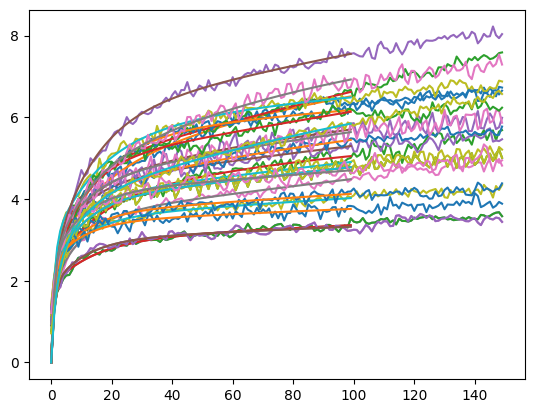

In [14]:
for nm,mname in enumerate(models):
    plt.plot(global_mean(CMIP_pattern_dict[mname].dacanom['tas'][1,:,:,:]))
    plt.plot(global_mean(recon(CMIP_pattern_dict[mname].pattern_dict['co2x4']['tas']['pattern_full'])[:,:,:]))


In [16]:
levels = [np.arange(-15,15.1,2), np.arange(-3e-5,3.1e-5,0.2e-5)]
cmaps = ["RdBu_r","BrBG"]
units = ["[K]","[kg m-2 s-1]"]

fig = plt.figure(figsize=(8,10), layout="tight")
gs = GridSpec(5, 2, figure=fig)

#### ------ row 1
varidx = 0
var ="tas"

sub = fig.add_subplot(gs[0, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('CMIP6', size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_GHG_response_co2x4[varidx,:,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('a', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[1, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR', size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nansum(np.nanmean(CMIP_GHG_response_recon_co2x4[varidx,:,:,:,:],0),0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('b', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[2, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title("Inter-annual mode \u03C4$_1$", size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_GHG_response_recon_co2x4[varidx,:,0,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('c', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[3, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title("Inter-decadal mode \u03C4$_2$", size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_GHG_response_recon_co2x4[varidx,:,1,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('d', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[4, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title("Inter-centennial mode \u03C4$_3$", size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_GHG_response_recon_co2x4[varidx,:,2,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('e', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# external colorbar
cbar = fig.add_axes([0.115, -0.02, 0.3, 0.011])
fig.colorbar(cont, cax=cbar, orientation='horizontal')
cbar.set_title(units[varidx], size=9, pad=5, ha="center")

#### ------ row 2
varidx = 1
var = "pr"

sub = fig.add_subplot(gs[0, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('CMIP6', size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_GHG_response_co2x4[varidx,:,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('f', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[1, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR', size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nansum(np.nanmean(CMIP_GHG_response_recon_co2x4[varidx,:,:,:,:],0),0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('g', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[2, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title("$GHG$ Inter-annual mode \u03C4$_1$", size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_GHG_response_recon_co2x4[varidx,:,0,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('h', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[3, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title("$GHG$ Inter-decadal mode \u03C4$_2$", size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_GHG_response_recon_co2x4[varidx,:,1,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('i', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[4, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title("$GHG$ Inter-centennial mode \u03C4$_3$", size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_GHG_response_recon_co2x4[varidx,:,2,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('j', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# external colorbar
cbar = fig.add_axes([0.61, -0.02, 0.3, 0.011])
fig.colorbar(cont, cax=cbar, orientation='horizontal')
cbar.set_title(units[varidx], size=9, pad=5, ha="center")

plt.savefig(os.path.join(figdir, "CMIP_GHG_pattern_composite.pdf"), bbox_inches='tight')
plt.close(fig)


/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_31633/1696333323.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir, "CMIP_GHG_pattern_composite.pdf"), bbox_inches='tight')
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_31633/1696333323.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir, "CMIP_GHG_pattern_composite.pdf"), bbox_inches='tight')


Run for all models

In [17]:
levels = [np.arange(-15,15.1,2), np.arange(-3e-5,3.1e-5,0.2e-5)]
cmaps = ["RdBu_r","BrBG"]

for nm,mname in enumerate(models):

    fig = plt.figure(figsize=(8,10), layout="tight")
    gs = GridSpec(5, 2, figure=fig)
    
    #### ------ row 1
    varidx = 0
    var ="tas"
    
    sub = fig.add_subplot(gs[0, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title(mname, size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_GHG_response_co2x4[varidx,nm,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('a', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[1, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('METEOR', size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, np.nansum(CMIP_GHG_response_recon_co2x4[varidx,nm,:,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('b', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[2, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title("Inter-annual mode \u03C4$_1$", size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_GHG_response_recon_co2x4[varidx,nm,0,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('c', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[3, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title("Inter-decadal mode \u03C4$_2$", size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_GHG_response_recon_co2x4[varidx,nm,1,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('d', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[4, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title("Inter-centennial mode \u03C4$_3$", size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_GHG_response_recon_co2x4[varidx,nm,2,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('e', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    # external colorbar
    cbar = fig.add_axes([0.115, -0.02, 0.3, 0.011])
    fig.colorbar(cont, cax=cbar, orientation='horizontal')
    cbar.set_title(units[varidx], size=9, pad=5, ha="center")

    #### ------ row 2
    varidx = 1
    var = "pr"
    
    sub = fig.add_subplot(gs[0, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title(mname, size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_GHG_response_co2x4[varidx,nm,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('f', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[1, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('METEOR', size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, np.nansum(CMIP_GHG_response_recon_co2x4[varidx,nm,:,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('g', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[2, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title("Inter-annual mode \u03C4$_1$", size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_GHG_response_recon_co2x4[varidx,nm,0,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('h', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[3, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title("Inter-decadal mode \u03C4$_2$", size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_GHG_response_recon_co2x4[varidx,nm,1,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('i', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[4, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title("Inter-centennial mode \u03C4$_3$", size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_GHG_response_recon_co2x4[varidx,nm,2,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('j', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    # external colorbar
    cbar = fig.add_axes([0.61, -0.02, 0.3, 0.011])
    fig.colorbar(cont, cax=cbar, orientation='horizontal')
    cbar.set_title(units[varidx], size=9, pad=5, ha="center")
    
    plt.savefig(os.path.join(figdir+"/CMIP_recon_patterns", "CMIP_GHG_pattern_composite_" + mname + ".pdf"), bbox_inches='tight')
    plt.close(fig)


/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_31633/1352697666.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir+"/CMIP_recon_patterns", "CMIP_GHG_pattern_composite_" + mname + ".pdf"), bbox_inches='tight')
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_31633/1352697666.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir+"/CMIP_recon_patterns", "CMIP_GHG_pattern_composite_" + mname + ".pdf"), bbox_inches='tight')
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_31633/1352697666.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir+"/CMIP_recon_patterns", "CMIP_GHG_pattern_composite_" + mname + ".pdf"), bbox_inches='tight')
/var/folders/mt/vkb75n9d7

# Aerosol patterns

In [20]:
%%capture
CMIP_aer_response_sulxanom = np.zeros([len(flds), len(models), len(common_lats), len(common_lons)]) * np.nan
CMIP_aer_response_recon_sulxanom = np.zeros([len(flds), len(models), 6, len(common_lats), len(common_lons)]) * np.nan

# Interpolate to native grid and data
for nv,var in enumerate(flds):
        for nm,mname in enumerate(models):
                # CMIP6
                native_data = np.nanmean(CMIP_pattern_dict[mname].dacanom[var][CMIP_pattern_dict[mname].exp_list.index('sulxanom'), 130:170, :, :],0)
                native_ds = xr.DataArray(native_data, dims=["lat", "lon"],
                                 coords={"lat": CMIP_pattern_dict[mname].dacanom[var].lat,
                                         "lon": CMIP_pattern_dict[mname].dacanom[var].lon})
                regridded_data = native_ds.interp(lat=common_lats, lon=common_lons, method="linear")
                CMIP_aer_response_sulxanom[nv, nm, :, :] = regridded_data.values

                # METEOR
                for mode in np.arange(0,6):
                    native_data = CMIP_pattern_dict[mname].predict_from_combined_experiment(em_data_fwd[1], conc_data_fwd[1], [var], return_patterns_per_mode=True)[var].isel(time=slice(230, 270)).mean(dim='time')[mode]
                    regridded_data = native_data.interp(lat=common_lats, lon=common_lons, method="linear")
                    CMIP_aer_response_recon_sulxanom[nv, nm, mode, :, :] = regridded_data.values

In [21]:
levels = [np.arange(-5,5.1,0.5), np.arange(-10e-6,10.1e-6,1e-6)]
cmaps = ["RdBu_r","BrBG"]
units = ["[K]","[kg m-2 s-1]"]

fig = plt.figure(figsize=(8,12), layout="tight")
gs = GridSpec(6, 2, figure=fig)

#### ------ row 1
varidx = 0
var ="tas"

sub = fig.add_subplot(gs[0, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('CMIP6', size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_aer_response_sulxanom[varidx,:,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('a', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[1, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR', size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nansum(np.nanmean(CMIP_aer_response_recon_sulxanom[varidx,:,:,:,:],0),0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('b', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[2, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('$GHG$ \u03C4$_1$+\u03C4$_2$+\u03C4$_3$', size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nansum(np.nanmean(CMIP_aer_response_recon_sulxanom[varidx,:,0:3,:,:],0),0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('c', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[3, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title("$aer$ Inter-annual mode \u03C4$_1$", size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_aer_response_recon_sulxanom[varidx,:,3,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('d', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[4, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title("$aer$ Inter-decadal mode \u03C4$_2$", size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_aer_response_recon_sulxanom[varidx,:,4,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('e', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[5, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title("$aer$ Inter-centennial mode \u03C4$_3$", size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_aer_response_recon_sulxanom[varidx,:,5,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('f', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# external colorbar
cbar = fig.add_axes([0.115, -0.02, 0.3, 0.011])
fig.colorbar(cont, cax=cbar, orientation='horizontal')
cbar.set_title(units[varidx], size=9, pad=5, ha="center")

#### ------ row 1
varidx = 1
var ="pr"

sub = fig.add_subplot(gs[0, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('CMIP6', size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_aer_response_sulxanom[varidx,:,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('g', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[1, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR', size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nansum(np.nanmean(CMIP_aer_response_recon_sulxanom[varidx,:,:,:,:],0),0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('h', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[2, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('$GHG$ \u03C4$_1$+\u03C4$_2$+\u03C4$_3$', size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nansum(np.nanmean(CMIP_aer_response_recon_sulxanom[varidx,:,0:3,:,:],0),0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('i', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[3, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title("$aer$ Inter-annual mode \u03C4$_1$", size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_aer_response_recon_sulxanom[varidx,:,3,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('j', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[4, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title("$aer$ Inter-decadal mode \u03C4$_2$", size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_aer_response_recon_sulxanom[varidx,:,4,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('k', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[5, varidx], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title("$aer$ Inter-centennial mode \u03C4$_3$", size=9)
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(CMIP_aer_response_recon_sulxanom[varidx,:,5,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
sub.annotate('l', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# external colorbar
cbar = fig.add_axes([0.61, -0.02, 0.3, 0.011])
fig.colorbar(cont, cax=cbar, orientation='horizontal')
cbar.set_title(units[varidx], size=9, pad=5, ha="center")

plt.savefig(os.path.join(figdir, "CMIP_aer_pattern_composite.pdf"), bbox_inches='tight')
plt.close(fig)


/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_31633/785777317.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir, "CMIP_aer_pattern_composite.pdf"), bbox_inches='tight')
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_31633/785777317.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir, "CMIP_aer_pattern_composite.pdf"), bbox_inches='tight')


Run for all models

In [22]:
levels = [np.arange(-5,5.1,0.5), np.arange(-10e-6,10.1e-6,1e-6)]
cmaps = ["RdBu_r","BrBG"]
units = ["[K]","[kg m-2 s-1]"]

for nm,mname in enumerate(models):

    fig = plt.figure(figsize=(8,12), layout="tight")
    gs = GridSpec(6, 2, figure=fig)
    
    #### ------ row 1
    varidx = 0
    var ="tas"
    
    sub = fig.add_subplot(gs[0, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title(mname, size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_aer_response_sulxanom[varidx,nm,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('a', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[1, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('METEOR', size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, np.nansum(CMIP_aer_response_recon_sulxanom[varidx,nm,:,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('b', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[2, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('$GHG$ \u03C4$_1$+\u03C4$_2$+\u03C4$_3$', size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, np.nansum(CMIP_aer_response_recon_sulxanom[varidx,nm,0:3,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('c', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[3, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title("$aer$ Inter-annual mode \u03C4$_1$", size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_aer_response_recon_sulxanom[varidx,nm,3,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('d', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[4, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title("$aer$ Inter-decadal mode \u03C4$_2$", size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_aer_response_recon_sulxanom[varidx,nm,4,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('e', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[5, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title("$aer$ Inter-centennial mode \u03C4$_3$", size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_aer_response_recon_sulxanom[varidx,nm,5,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('f', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    # external colorbar
    cbar = fig.add_axes([0.115, -0.02, 0.3, 0.011])
    fig.colorbar(cont, cax=cbar, orientation='horizontal')
    cbar.set_title(units[varidx], size=9, pad=5, ha="center")
    
    #### ------ row 1
    varidx = 1
    var ="pr"
    
    sub = fig.add_subplot(gs[0, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('CMIP6', size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_aer_response_sulxanom[varidx,nm,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('g', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[1, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('METEOR', size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, np.nansum(CMIP_aer_response_recon_sulxanom[varidx,nm,:,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('h', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[2, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title('$GHG$ \u03C4$_1$+\u03C4$_2$+\u03C4$_3$', size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, np.nansum(CMIP_aer_response_recon_sulxanom[varidx,nm,0:3,:,:],0), cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('i', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[3, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title("$aer$ Inter-annual mode \u03C4$_1$", size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_aer_response_recon_sulxanom[varidx,nm,3,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('j', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[4, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title("$aer$ Inter-decadal mode \u03C4$_2$", size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_aer_response_recon_sulxanom[varidx,nm,4,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('k', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    sub = fig.add_subplot(gs[5, varidx], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_title("$aer$ Inter-centennial mode \u03C4$_3$", size=9)
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    cont = sub.contourf(common_lons, common_lats, CMIP_aer_response_recon_sulxanom[varidx,nm,5,:,:], cmap=cmaps[varidx], levels=levels[varidx], extend="both", transform=cart.crs.PlateCarree())
    sub.annotate('l', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    
    # external colorbar
    cbar = fig.add_axes([0.605, -0.02, 0.3, 0.011])
    fig.colorbar(cont, cax=cbar, orientation='horizontal')
    cbar.set_title(units[varidx], size=9, pad=5, ha="center")
    
    plt.savefig(os.path.join(figdir+"/CMIP_recon_patterns", "CMIP_aer_pattern_composite_" + mname + ".pdf"), bbox_inches='tight')
    plt.close(fig)


/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_31633/1184189399.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir+"/CMIP_recon_patterns", "CMIP_aer_pattern_composite_" + mname + ".pdf"), bbox_inches='tight')
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_31633/1184189399.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir+"/CMIP_recon_patterns", "CMIP_aer_pattern_composite_" + mname + ".pdf"), bbox_inches='tight')
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_31633/1184189399.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(figdir+"/CMIP_recon_patterns", "CMIP_aer_pattern_composite_" + mname + ".pdf"), bbox_inches='tight')
/var/folders/mt/vkb75n9d7